# Dask vs Pandas Benchmark

Compare wall time for data ingestion and cleaning on the full dataset.
The pattern matters more than raw speedup on a single machine —
Dask scales horizontally, Pandas does not.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import dask.dataframe as dd
import time
import matplotlib.pyplot as plt
import numpy as np

## Step 1: Generate sample data (simulating 9-year Tariff dataset)

If you have your actual Tariff CSV, point `CSV_PATH` to it.

In [2]:
np.random.seed(42)
dates = pd.date_range("2015-01-01", "2024-12-31", freq="D")
n = len(dates)

data = {
    "Date": dates,
    "UBER_Close": 30 + np.cumsum(np.random.randn(n) * 0.5),
    "UBER_Volume": np.random.randint(5_000_000, 50_000_000, n),
    "SPY_Close": 250 + np.cumsum(np.random.randn(n) * 0.3),
    "SPY_Volume": np.random.randint(50_000_000, 200_000_000, n),
    "EUR_USD": 1.1 + np.cumsum(np.random.randn(n) * 0.002),
    "DGS10": 2.5 + np.cumsum(np.random.randn(n) * 0.01),
    "VIX": 15 + np.abs(np.cumsum(np.random.randn(n) * 0.3)),
}

df_sample = pd.DataFrame(data)
# Inject some NaNs
for col in ["UBER_Close", "SPY_Close", "EUR_USD"]:
    mask = np.random.random(n) < 0.02
    df_sample.loc[mask, col] = np.nan

CSV_PATH = "../data/benchmark_dataset.csv"
df_sample.to_csv(CSV_PATH, index=False)
print(f"Sample dataset saved: {df_sample.shape}")

Sample dataset saved: (3653, 8)


## Step 2: Pandas Benchmark

In [3]:
pandas_times = []
for i in range(5):
    start = time.time()
    pdf = pd.read_csv(CSV_PATH, parse_dates=["Date"])
    pdf = pdf.set_index("Date")
    pdf = pdf.ffill().interpolate(method="linear").bfill()
    stats = pdf.describe()
    elapsed = time.time() - start
    pandas_times.append(elapsed)
    print(f"  Pandas run {i+1}: {elapsed:.4f}s")

print(f"\nPandas average: {np.mean(pandas_times):.4f}s")

  Pandas run 1: 0.0959s
  Pandas run 2: 0.0320s
  Pandas run 3: 0.0297s
  Pandas run 4: 0.0278s
  Pandas run 5: 0.0310s

Pandas average: 0.0433s


## Step 3: Dask Benchmark

In [4]:
dask_times = []
for i in range(5):
    start = time.time()
    ddf = dd.read_csv(CSV_PATH, parse_dates=["Date"], assume_missing=True)
    ddf = ddf.ffill()
    result = ddf.compute()
    result = result.set_index("Date")
    result = result.interpolate(method="linear").bfill()
    stats = result.describe()
    elapsed = time.time() - start
    dask_times.append(elapsed)
    print(f"  Dask run {i+1}: {elapsed:.4f}s")

print(f"\nDask average: {np.mean(dask_times):.4f}s")

  Dask run 1: 0.1044s
  Dask run 2: 0.0490s
  Dask run 3: 0.0676s
  Dask run 4: 0.0634s
  Dask run 5: 0.0583s

Dask average: 0.0685s


## Step 4: Comparison Chart

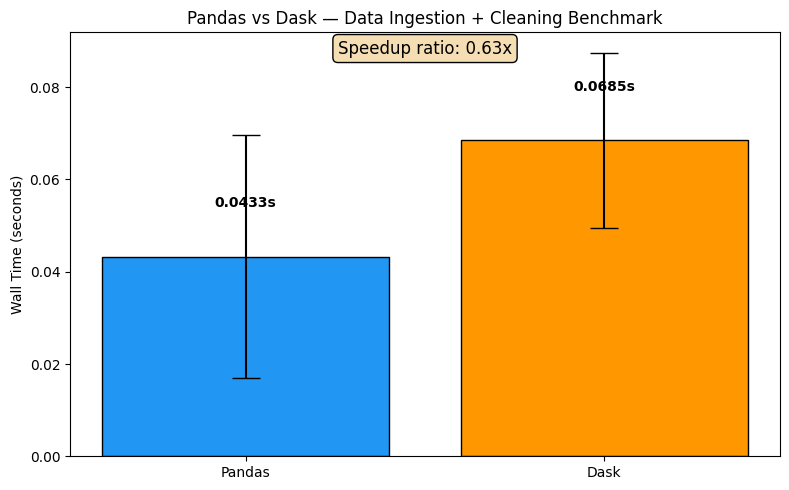

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Pandas", "Dask"]
means = [np.mean(pandas_times), np.mean(dask_times)]
stds = [np.std(pandas_times), np.std(dask_times)]

bars = ax.bar(labels, means, yerr=stds, capsize=10, color=["#2196F3", "#FF9800"], edgecolor="black")
ax.set_ylabel("Wall Time (seconds)")
ax.set_title("Pandas vs Dask — Data Ingestion + Cleaning Benchmark")

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{mean:.4f}s", ha="center", va="bottom", fontweight="bold")

speedup = np.mean(pandas_times) / np.mean(dask_times)
ax.text(0.5, 0.95, f"Speedup ratio: {speedup:.2f}x",
        transform=ax.transAxes, ha="center", fontsize=12,
        bbox=dict(boxstyle="round", facecolor="wheat"))

plt.tight_layout()
plt.savefig("../data/benchmark_comparison.png", dpi=150)
plt.show()

## Key Takeaway

On a single machine with this dataset size, Dask may not be faster (or could even be slower due to scheduling overhead).
**The value of Dask is the pattern:**
- Lazy computation with `.compute()` as the trigger
- Horizontal scaling across a cluster with zero code changes  
- Memory efficiency via partitioned processing
- Production readiness for datasets that don't fit in RAM